In [5]:
# Cell 1: Imports & Data Loading
# - pandas, statsmodels, matplotlib/seaborn


import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# - Load the "Combined" tab from the xlsx
df = pd.read_excel('DataAppendixNCG.xlsx', sheet_name='Combined')

# quick check 
print(df.shape)



(4000, 10)


In [6]:
# Cell 2: Data Cleaning & Prep
# - Rename columns for readability
# - Confirm variable coding (the key from the sheet)
# - Check for nulls, basic shape confirmation
# - Convert categorical codes to dummy variables
#   (GMAT, School Ranking, Class Ranking, Practice Area, 
#    Experience, Industry Background, WP Flag)
# - Set reference categories (pick the lowest-performing 
#   group as baseline so coefficients are intuitive)

# Cell 2: Data Cleaning & Prep

# Drop any unnamed/empty columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Rename columns for readability
df.columns = ['Employee_ID', 'GMAT', 'School_Rank', 'Class_Rank', 
              'Practice_Area', 'Work_Experience', 'Industry_Background', 
              'Signing_Bonus', 'WP_Flag', 'Performance_Score']

# Variable coding key (from the dataset):
# GMAT:              1 = 700-800, 2 = 600-700, 3 = <600
# School_Rank:       1 = Top 20, 2 = 21-40, 3 = 41-60
# Class_Rank:        1 = Top 10%, 2 = 10-25%, 3 = >25%
# Practice_Area:     1 = M&A, 2 = New Market Strategy, 3 = All other
# Work_Experience:   1 = 0-1 yrs, 2 = 2-5 yrs, 3 = 6-10 yrs
# Industry_Background: 1 = Consulting/Finance, 2 = Non-Consulting/Finance
# WP_Flag:           0 = MBA Graduate, 1 = Working Professional

# Create dummy variables, dropping the lowest-performing category as baseline
df['GMAT_700_800'] = (df['GMAT'] == 1).astype(int)
df['GMAT_sub600'] = (df['GMAT'] == 3).astype(int)
# baseline: GMAT 600-700 (code 2) — lowest performer for MBAs

df['School_Top20'] = (df['School_Rank'] == 1).astype(int)
df['School_21_40'] = (df['School_Rank'] == 2).astype(int)
# baseline: Schools 41-60 (code 3)

df['Class_Top10'] = (df['Class_Rank'] == 1).astype(int)
df['Class_10_25'] = (df['Class_Rank'] == 2).astype(int)
# baseline: >25th percentile (code 3)

df['Practice_MA'] = (df['Practice_Area'] == 1).astype(int)
df['Practice_NMS'] = (df['Practice_Area'] == 2).astype(int)
# baseline: All other areas (code 3)

df['Exp_2_5'] = (df['Work_Experience'] == 2).astype(int)
df['Exp_6_10'] = (df['Work_Experience'] == 3).astype(int)
# baseline: 0-1 years (code 1)

df['Consulting_Finance'] = (df['Industry_Background'] == 1).astype(int)
# baseline: Non-Consulting/Finance (code 2)

print(f"Shape after prep: {df.shape}")
print(f"\nNull check:\n{df.isnull().sum()}")
df.head()

Shape after prep: (4000, 21)

Null check:
Employee_ID            0
GMAT                   0
School_Rank            0
Class_Rank             0
Practice_Area          0
Work_Experience        0
Industry_Background    0
Signing_Bonus          0
WP_Flag                0
Performance_Score      0
GMAT_700_800           0
GMAT_sub600            0
School_Top20           0
School_21_40           0
Class_Top10            0
Class_10_25            0
Practice_MA            0
Practice_NMS           0
Exp_2_5                0
Exp_6_10               0
Consulting_Finance     0
dtype: int64


,Employee_ID,GMAT,School_Rank,Class_Rank,Practice_Area,Work_Experience,Industry_Background,Signing_Bonus,WP_Flag,Performance_Score,...,GMAT_sub600,School_Top20,School_21_40,Class_Top10,Class_10_25,Practice_MA,Practice_NMS,Exp_2_5,Exp_6_10,Consulting_Finance
0,1,2,3,2,1,2,2,18836.323567,0,4.86,...,0,0,0,0,1,1,0,1,0,0
1,2,3,2,2,2,2,1,18356.573174,0,4.81,...,1,0,1,0,1,0,1,1,0,1
2,3,3,1,2,2,2,2,20275.521020,0,4.78,...,1,1,0,0,1,0,1,1,0,0
3,4,1,2,2,1,2,2,22788.924330,0,4.76,...,0,0,1,0,1,1,0,1,0,0
4,5,1,1,2,2,2,1,20269.179689,0,4.76,...,0,1,0,0,1,0,1,1,0,1


In [7]:
# Cell 3: Descriptive Statistics
# - df.describe() and df.groupby() means by category
# - Recreate Table 1 from your own data to confirm 
#   you're reading the dataset correctly

# Cell 3: Descriptive Statistics — Recreating Table 1

# Overall summary
print("=== Overall Summary ===")
print(df[['Performance_Score', 'Signing_Bonus']].describe().round(2))

# Define label mappings for clean output
label_maps = {
    'GMAT': {1: '700-800', 2: '600-700', 3: '<600'},
    'School_Rank': {1: 'Top 20', 2: '21-40', 3: '41-60'},
    'Class_Rank': {1: 'Top 10%', 2: '10-25%', 3: '>25%'},
    'Practice_Area': {1: 'M&A', 2: 'New Market Strategy', 3: 'All Other'},
    'Work_Experience': {1: '0-1 yrs', 2: '2-5 yrs', 3: '6-10 yrs'},
    'Industry_Background': {1: 'Consulting/Finance', 2: 'Other'}
}

pool_labels = {0: 'MBA', 1: 'Working Professional'}

# Recreate Table 1: Mean performance by category and pool
print("\n=== Performance by Category and Candidate Pool ===\n")

for var, labels in label_maps.items():
    table = df.pivot_table(
        values='Performance_Score', 
        index=var, 
        columns='WP_Flag', 
        aggfunc='mean'
    ).round(2)
    table.index = table.index.map(labels)
    table.columns = [pool_labels[c] for c in table.columns]
    print(f"--- {var} ---")
    print(table)
    print()

# Signing bonus comparison
print("--- Average Signing Bonus ---")
print(df.groupby('WP_Flag')['Signing_Bonus'].mean().round(0).rename(index=pool_labels))

=== Overall Summary ===
       Performance_Score  Signing_Bonus
count            4000.00        4000.00
mean                4.09       25000.00
std                 0.41        5602.86
min                 2.48       12870.91
25%                 3.81       20018.29
50%                 4.20       23981.31
75%                 4.39       29988.56
max                 4.86       41227.66

=== Performance by Category and Candidate Pool ===

--- GMAT ---
          MBA  Working Professional
GMAT                               
700-800  4.56                  4.37
600-700  3.68                  4.06
<600     4.21                  3.80

--- School_Rank ---
              MBA  Working Professional
School_Rank                            
Top 20       4.56                  4.24
21-40        4.19                  4.15
41-60        3.53                  3.81

--- Class_Rank ---
             MBA  Working Professional
Class_Rank                            
Top 10%     4.29                  4.38
10-25%      

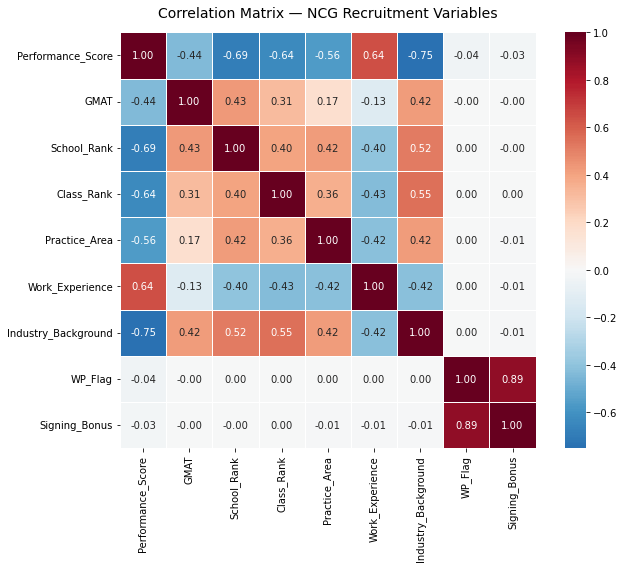

In [8]:
# Cell 4: Correlation Matrix
# - Quick heatmap of variable relationships

# Cell 4: Correlation Matrix

# Select the variables we care about
corr_vars = ['Performance_Score', 'GMAT', 'School_Rank', 'Class_Rank', 
             'Practice_Area', 'Work_Experience', 'Industry_Background', 
             'WP_Flag', 'Signing_Bonus']

corr_matrix = df[corr_vars].corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Matrix — NCG Recruitment Variables', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [9]:
# Cell 5: OLS Regression
# - DV: Performance Review Score
# - IVs: All demographic dummies + WP Flag + Signing Bonus
# - Use statsmodels OLS for clean summary output
# - Print the summary table

# Cell 5: OLS Regression — Predicting Performance Review Score

# Independent variables (dummy variables we created in Cell 2)
X = df[['GMAT_700_800', 'GMAT_sub600', 
        'School_Top20', 'School_21_40',
        'Class_Top10', 'Class_10_25',
        'Practice_MA', 'Practice_NMS',
        'Exp_2_5', 'Exp_6_10',
        'Consulting_Finance',
        'WP_Flag']]

# Add constant (intercept)
X = sm.add_constant(X)

# Dependent variable
y = df['Performance_Score']

# Fit the model
model = sm.OLS(y, X).fit()

# Print full summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:      Performance_Score   R-squared:                       0.866
Model:                            OLS   Adj. R-squared:                  0.866
Method:                 Least Squares   F-statistic:                     2149.
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        22:38:26   Log-Likelihood:                 1902.4
No. Observations:                4000   AIC:                            -3779.
Df Residuals:                    3987   BIC:                            -3697.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  3.4718      0

C:\Users\ikenn\anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only.
  x = pd.concat(x[::order], 1)


In [10]:
# Cell 6: Interpretation
# - Markdown cell explaining key coefficients 
#   in plain language
# - Which predictors matter most?
# - Does the model confirm Table 1's patterns?


# Cell 6: Interpretation Summary

# Create a clean coefficient table sorted by impact
results = pd.DataFrame({
    'Variable': model.params.index,
    'Coefficient': model.params.values,
    'P_Value': model.pvalues.values
}).query("Variable != 'const'").sort_values('Coefficient', ascending=False)

results['Coefficient'] = results['Coefficient'].round(4)
results['P_Value'] = results['P_Value'].round(4)

print("=" * 60)
print("INTERPRETATION SUMMARY")
print("=" * 60)
print(f"\nModel R²: {model.rsquared:.3f}")
print(f"All predictors significant at p < 0.001")
print(f"\nCoefficients ranked by size (relative to baseline):\n")
print(results.to_string(index=False))

print("""
\n--- Key Takeaways ---

1. EXPERIENCE is the strongest predictor. Having 2+ years 
   of work experience adds ~0.4 points to performance vs. 
   candidates with 0-1 years. No additional benefit past 5 years.

2. SCHOOL RANKING matters. Top-20 grads score ~0.18 points 
   higher than tier 41-60 grads, even after controlling for 
   GMAT, class rank, and experience.

3. CONSULTING/FINANCE BACKGROUND adds ~0.14 points. 
   Industry familiarity translates to better performance 
   at NCG regardless of other credentials.

4. GMAT follows a non-linear pattern. 700-800 adds ~0.14 
   points over the 600-700 baseline. Sub-600 also slightly 
   outperforms 600-700 — the middle range is the weakest.

5. CLASS RANK has a threshold effect. Top 10% (+0.13) and 
   10-25% (+0.12) are nearly identical. The real drop-off 
   is below the 25th percentile.

6. WORKING PROFESSIONALS slightly underperform MBAs (-0.03) 
   after controlling for all other factors — and cost $10K 
   more in signing bonuses. The cost-performance case favors 
   tilting toward the MBA pipeline.
""")

INTERPRETATION SUMMARY

Model R²: 0.866
All predictors significant at p < 0.001

Coefficients ranked by size (relative to baseline):

          Variable  Coefficient  P_Value
           Exp_2_5       0.3972      0.0
          Exp_6_10       0.3620      0.0
      School_Top20       0.1764      0.0
      GMAT_700_800       0.1374      0.0
Consulting_Finance       0.1362      0.0
       Class_Top10       0.1317      0.0
       Class_10_25       0.1214      0.0
      School_21_40       0.1030      0.0
      Practice_NMS       0.0955      0.0
       Practice_MA       0.0925      0.0
       GMAT_sub600       0.0267      0.0
           WP_Flag      -0.0320      0.0


--- Key Takeaways ---

1. EXPERIENCE is the strongest predictor. Having 2+ years 
   of work experience adds ~0.4 points to performance vs. 
   candidates with 0-1 years. No additional benefit past 5 years.

2. SCHOOL RANKING matters. Top-20 grads score ~0.18 points 
   higher than tier 41-60 grads, even after controlling for 
  

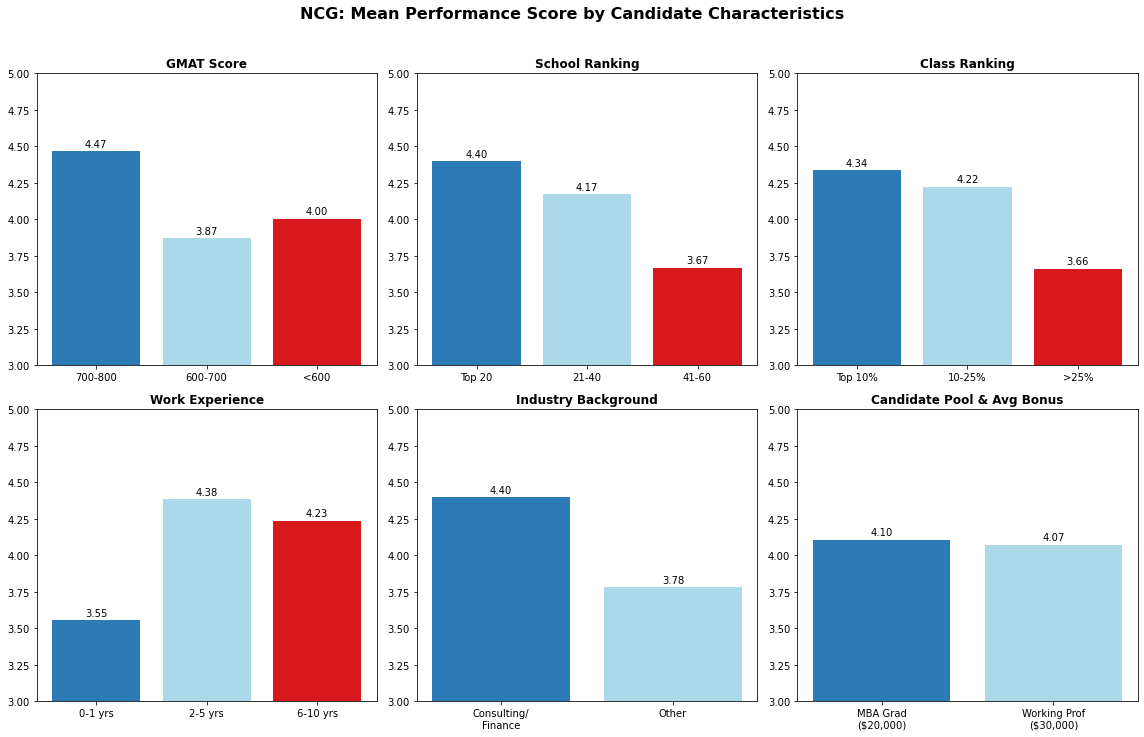


Chart saved as 'ncg_performance_charts.png'


In [11]:
# Cell 7: (Bonus) Visualizations
# - Bar charts of mean performance by category
# - Good for the appendix

# Cell 7: Visualizations for Appendix

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('NCG: Mean Performance Score by Candidate Characteristics', 
             fontsize=16, fontweight='bold', y=1.02)

# Color palette
colors = ['#2c7bb6', '#abd9e9', '#d7191c']

# 1. GMAT
ax = axes[0, 0]
data = df.groupby('GMAT')['Performance_Score'].mean()
bars = ax.bar(['700-800', '600-700', '<600'], 
              [data[1], data[2], data[3]], color=colors)
ax.set_title('GMAT Score', fontweight='bold')
ax.set_ylim(3.0, 5.0)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, 
            f'{bar.get_height():.2f}', ha='center', fontsize=10)

# 2. School Ranking
ax = axes[0, 1]
data = df.groupby('School_Rank')['Performance_Score'].mean()
bars = ax.bar(['Top 20', '21-40', '41-60'], 
              [data[1], data[2], data[3]], color=colors)
ax.set_title('School Ranking', fontweight='bold')
ax.set_ylim(3.0, 5.0)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, 
            f'{bar.get_height():.2f}', ha='center', fontsize=10)

# 3. Class Rank
ax = axes[0, 2]
data = df.groupby('Class_Rank')['Performance_Score'].mean()
bars = ax.bar(['Top 10%', '10-25%', '>25%'], 
              [data[1], data[2], data[3]], color=colors)
ax.set_title('Class Ranking', fontweight='bold')
ax.set_ylim(3.0, 5.0)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, 
            f'{bar.get_height():.2f}', ha='center', fontsize=10)

# 4. Work Experience
ax = axes[1, 0]
data = df.groupby('Work_Experience')['Performance_Score'].mean()
bars = ax.bar(['0-1 yrs', '2-5 yrs', '6-10 yrs'], 
              [data[1], data[2], data[3]], color=colors)
ax.set_title('Work Experience', fontweight='bold')
ax.set_ylim(3.0, 5.0)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, 
            f'{bar.get_height():.2f}', ha='center', fontsize=10)

# 5. Industry Background
ax = axes[1, 1]
data = df.groupby('Industry_Background')['Performance_Score'].mean()
bars = ax.bar(['Consulting/\nFinance', 'Other'], 
              [data[1], data[2]], color=colors[:2])
ax.set_title('Industry Background', fontweight='bold')
ax.set_ylim(3.0, 5.0)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, 
            f'{bar.get_height():.2f}', ha='center', fontsize=10)

# 6. MBA vs Working Professional
ax = axes[1, 2]
data = df.groupby('WP_Flag')['Performance_Score'].mean()
bonus = df.groupby('WP_Flag')['Signing_Bonus'].mean()
bars = ax.bar(['MBA Grad\n($' + f'{bonus[0]:,.0f})', 
               'Working Prof\n($' + f'{bonus[1]:,.0f})'], 
              [data[0], data[1]], color=colors[:2])
ax.set_title('Candidate Pool & Avg Bonus', fontweight='bold')
ax.set_ylim(3.0, 5.0)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, 
            f'{bar.get_height():.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('ncg_performance_charts.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved as 'ncg_performance_charts.png'")